# Language Detection

## Notebook Overview

This notebook builds a **lightweight, classical NLP-based language detection model** as a preprocessing component for the RAG-Based Mental Health Chatbot. Before routing any user query to the chatbot's pipeline, we first need to determine whether the input is written in a **supported language** (English). This notebook trains, compares, and saves that detection model.

## Import Packages

In [1]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

## Dataset

We use the [**papluca/language-identification**](https://huggingface.co/datasets/papluca/language-identification) dataset from Hugging Face, which contains text samples across **20 languages**:
`ar, bg, de, el, en, es, fr, hi, it, ja, nl, pl, pt, ru, sw, th, tr, ur, vi, zh`
The dataset is **perfectly balanced** — each language has an equal number of samples — confirmed via an exploratory bar chart.  
- **Train split**: ~70,000 samples  
- **Validation split**: 10,000 samples (500 per language)  
- **Test split**: 10,000 samples (500 per language)

## Load Dataset

In [2]:
dataset = load_dataset("papluca/language-identification")

dataset["train"].to_csv("../data/language_identification/train.csv")
dataset["test"].to_csv("../data/language_identification/test.csv")
dataset["validation"].to_csv("../data/language_identification/validation.csv")

Creating CSV from Arrow format:   0%|          | 0/70 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

1715421

In [3]:
df_train = pd.read_csv('../data/language_identification/train.csv')
df_train.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


## Data Exploration

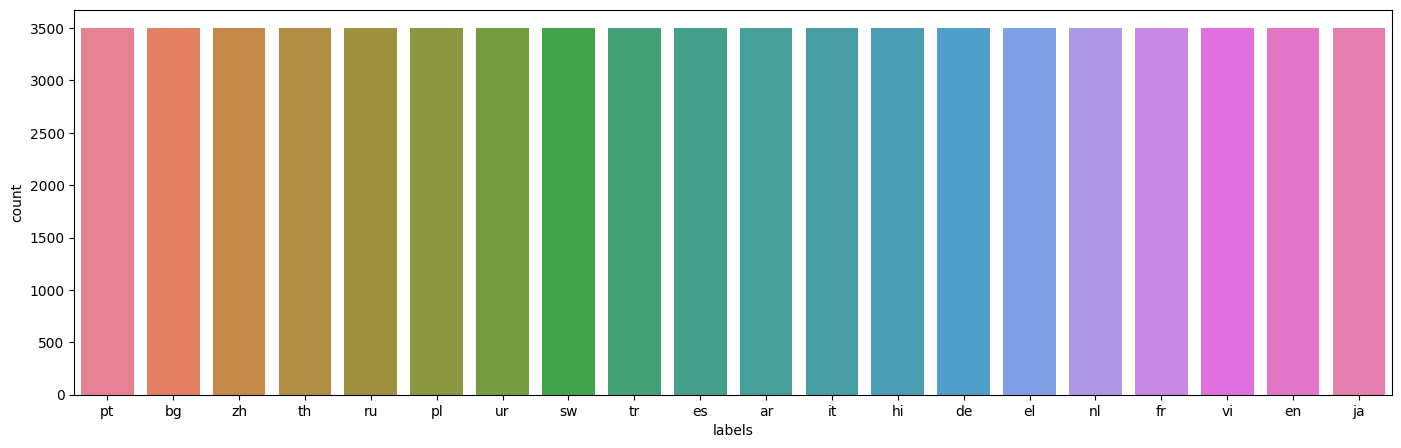

In [4]:
plt.figure(figsize=(17,5))
sns.countplot(data=df_train, x='labels', hue='labels')
plt.show()

## Model Training

In [5]:
df_val = pd.read_csv('../data/language_identification/validation.csv')
X_train, y_train = df_train['text'], df_train['labels']
X_val,   y_val   = df_val['text'], df_val['labels']

### Logistic Regression

In [6]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 3), max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [7]:
preds = lr_pipeline.predict(X_val)
report = classification_report(y_val, preds, output_dict=True)
df_report = pd.DataFrame(report).T
print(df_report.round(2))

              precision  recall  f1-score   support
ar                 1.00    0.99      1.00    500.00
bg                 0.99    0.99      0.99    500.00
de                 1.00    0.99      1.00    500.00
el                 1.00    1.00      1.00    500.00
en                 0.99    1.00      0.99    500.00
es                 1.00    0.99      0.99    500.00
fr                 1.00    1.00      1.00    500.00
hi                 1.00    0.95      0.98    500.00
it                 0.99    1.00      1.00    500.00
ja                 1.00    1.00      1.00    500.00
nl                 0.98    1.00      0.99    500.00
pl                 1.00    1.00      1.00    500.00
pt                 0.99    0.99      0.99    500.00
ru                 0.99    0.99      0.99    500.00
sw                 0.94    1.00      0.97    500.00
th                 1.00    1.00      1.00    500.00
tr                 1.00    1.00      1.00    500.00
ur                 1.00    0.97      0.98    500.00
vi          

### Naive Bayes

In [8]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 3), max_features=5000)),
    ("clf", MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [9]:
preds = nb_pipeline.predict(X_val)
report = classification_report(y_val, preds, output_dict=True)
df_report = pd.DataFrame(report).T
print(df_report.round(2))

              precision  recall  f1-score   support
ar                 1.00    0.99      1.00    500.00
bg                 0.99    1.00      1.00    500.00
de                 1.00    1.00      1.00    500.00
el                 1.00    1.00      1.00    500.00
en                 0.99    1.00      0.99    500.00
es                 1.00    0.99      0.99    500.00
fr                 1.00    1.00      1.00    500.00
hi                 1.00    0.95      0.98    500.00
it                 0.99    1.00      0.99    500.00
ja                 1.00    1.00      1.00    500.00
nl                 0.98    1.00      0.99    500.00
pl                 1.00    1.00      1.00    500.00
pt                 0.99    0.99      0.99    500.00
ru                 1.00    0.99      1.00    500.00
sw                 0.94    1.00      0.97    500.00
th                 1.00    1.00      1.00    500.00
tr                 1.00    1.00      1.00    500.00
ur                 1.00    0.97      0.98    500.00
vi          

### K-Nearest Neighbors


In [10]:
knn_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 3), max_features=5000)),
    ("clf", KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1))
])

knn_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [11]:
preds = knn_pipeline.predict(X_val)
report = classification_report(y_val, preds, output_dict=True)
df_report = pd.DataFrame(report).T
print(df_report.round(2))

              precision  recall  f1-score   support
ar                 1.00    0.99      1.00    500.00
bg                 0.95    1.00      0.97    500.00
de                 0.96    1.00      0.98    500.00
el                 1.00    1.00      1.00    500.00
en                 0.97    1.00      0.98    500.00
es                 0.73    1.00      0.85    500.00
fr                 0.99    1.00      0.99    500.00
hi                 1.00    0.95      0.98    500.00
it                 0.99    0.90      0.94    500.00
ja                 1.00    0.99      1.00    500.00
nl                 0.99    0.96      0.98    500.00
pl                 1.00    0.99      0.99    500.00
pt                 1.00    0.74      0.85    500.00
ru                 1.00    0.95      0.97    500.00
sw                 0.94    1.00      0.97    500.00
th                 1.00    1.00      1.00    500.00
tr                 1.00    0.99      0.99    500.00
ur                 1.00    0.97      0.98    500.00
vi          

### Models Trained

Three classifiers were benchmarked, each inside a `sklearn.pipeline.Pipeline` combining the char-level TF-IDF vectorizer with a classifier:
| Model | Validation Accuracy |
|---|---|
| **Multinomial Naive Bayes** | **99%** |
| Logistic Regression (`max_iter=1000`) | **99%** |
| K-Nearest Neighbors (`k=5`, cosine metric) | **97%** |


## Model Evaluation

In [12]:
df_test = pd.read_csv('../data/language_identification/test.csv')
X_test, y_test = df_test['text'], df_test['labels']

In [13]:
preds = nb_pipeline.predict(X_test)
report = classification_report(y_test, preds, output_dict=True)
df_report = pd.DataFrame(report).T
print(df_report.round(2))

              precision  recall  f1-score   support
ar                 1.00    1.00      1.00    500.00
bg                 0.99    1.00      1.00    500.00
de                 1.00    1.00      1.00    500.00
el                 1.00    1.00      1.00    500.00
en                 0.98    1.00      0.99    500.00
es                 0.97    1.00      0.99    500.00
fr                 0.99    1.00      1.00    500.00
hi                 1.00    0.97      0.98    500.00
it                 0.99    0.99      0.99    500.00
ja                 1.00    1.00      1.00    500.00
nl                 1.00    1.00      1.00    500.00
pl                 1.00    0.99      0.99    500.00
pt                 1.00    0.97      0.98    500.00
ru                 1.00    0.99      1.00    500.00
sw                 0.94    1.00      0.97    500.00
th                 1.00    1.00      1.00    500.00
tr                 1.00    1.00      1.00    500.00
ur                 1.00    0.96      0.98    500.00
vi          

## Model Saving

In [14]:
joblib.dump(nb_pipeline, "../models/language_detector.pkl")

['../models/language_detector.pkl']